In [113]:
import pandas as pd
df=pd.read_csv("/root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1/Sentiment Analysis for Mental Health.csv")

In [114]:
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


##data information or EDA



In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27639 entries, 0 to 27638
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  27639 non-null  int64 
 1   statement   27629 non-null  object
 2   status      27639 non-null  object
dtypes: int64(1), object(2)
memory usage: 647.9+ KB


In [116]:
df.shape

(27639, 3)

In [117]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress'],
      dtype=object)

In [118]:
df.columns

Index(['Unnamed: 0', 'statement', 'status'], dtype='object')

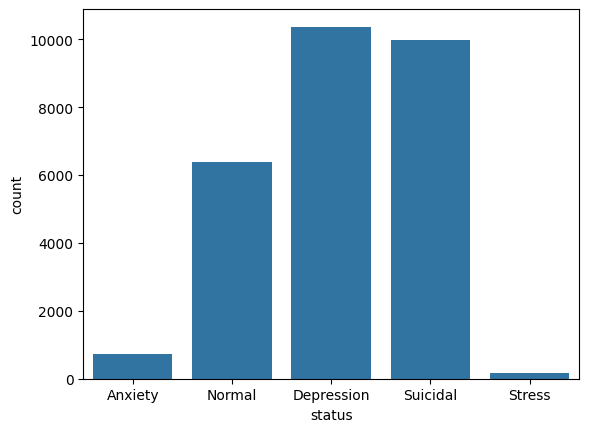

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='status',data=df)
plt.show()

In [120]:
df['status'].value_counts()

status
Depression    10371
Suicidal       9993
Normal         6383
Anxiety         733
Stress          159
Name: count, dtype: int64

In [121]:
df=df.drop(['Unnamed: 0'],axis=1)
df.head(5)

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [122]:
df.sample(10)

,statement,status
1907,awiwit ?_?,Normal
24878,I really need to express some thoughts to some...,Depression
8507,"I had a job interview today, it went like shit...",Depression
26259,ill keep this as short and sweet as I can. I l...,Depression
15902,Therese this person struggle with substance ab...,Depression
4825,I pray,Normal
19273,"Hi, i am Andrei, i am 20 years old and i suffe...",Depression
19601,Comence terapia e [opcionyo.com]( cambio la vi...,Depression
21715,I had intentional overdose on my antidepressan...,Depression
12344,I have been talking to this girl for 4 months....,Depression


In [123]:
df.duplicated().sum()

np.int64(100)

In [124]:
df.drop_duplicates(inplace=True)

In [125]:
df.duplicated().sum()

np.int64(0)

In [126]:
df.isnull().sum()

statement    2
status       0
dtype: int64

In [127]:
df=df.dropna()

##handling class impalns


In [128]:
%uv pip install kagglehub

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 5ms
Note: you may need to restart the kernel to use updated packages.


In [129]:
#load orignal data set as take from it two classes (Stress,Anxiety)
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1


In [130]:
orignal_df = pd.read_csv("/root/.cache/kagglehub/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/versions/1/Combined Data.csv")

In [131]:
orignal_df=orignal_df.drop(['Unnamed: 0'],axis=1)

In [132]:
for i in ['Bipolar','Personality disorder','Depression','Suicidal','Normal']:
  orignal_df = orignal_df[orignal_df['status'] != i]


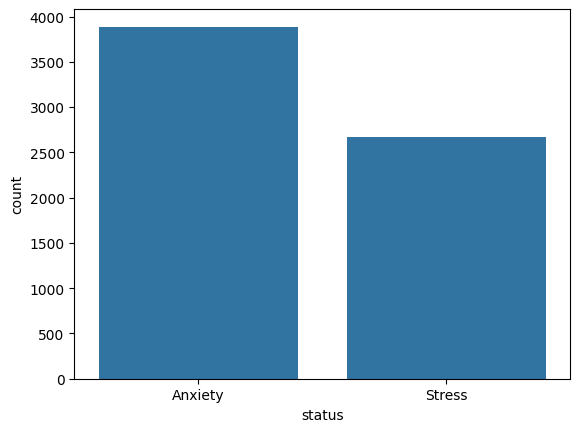

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='status',data=orignal_df)
plt.show()

In [134]:
#data palnce (marge old data with orgnal data)
new_df = pd.concat([df, orignal_df], ignore_index=True)

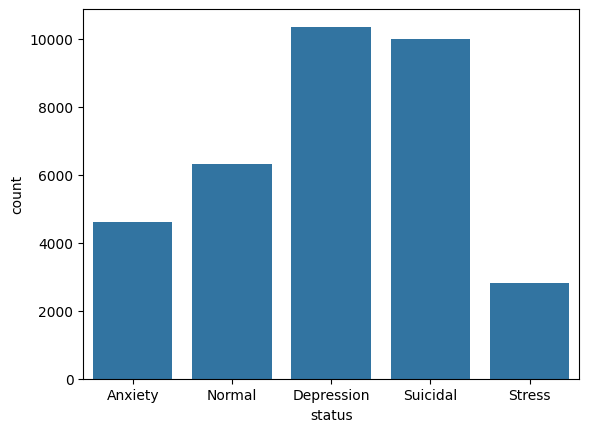

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='status',data=new_df)
plt.show()

In [136]:
new_df = new_df.dropna()

##data agmentation by nltk

In [137]:
%uv pip install nltk

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 6ms
Note: you may need to restart the kernel to use updated packages.


In [138]:
import random
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [139]:
def get_synonyms(word):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    return list(synonyms)

In [140]:
def synonym_replacement(sentence, n=5):
    words = word_tokenize(sentence)
    words_to_replace = random.sample(words, min(n, len(words)))

    new_words = words.copy()
    for word in words_to_replace:
        synonyms = get_synonyms(word)
        if synonyms:
            synonym = random.choice(synonyms)
            new_words = [synonym if w == word else w for w in new_words]

    return " ".join(new_words)

In [141]:
augmented_df = new_df.copy()
for i in ['Stress', 'Anxiety']:
    minority_df = new_df[new_df['status'] == i].copy()
    minority_df['statement'] = minority_df['statement'].apply(
        lambda x: synonym_replacement(x, n=5)
    )
    augmented_df = pd.concat([augmented_df, minority_df], ignore_index=True)

In [142]:
augmented_df = augmented_df.reset_index(drop=True)


In [143]:
augmented_df.duplicated().sum()

np.int64(1386)

In [144]:
augmented_df.drop_duplicates(inplace=True)

In [145]:
augmented_df.duplicated().sum()

np.int64(0)

In [146]:
augmented_df.isnull().sum()

statement    0
status       0
dtype: int64

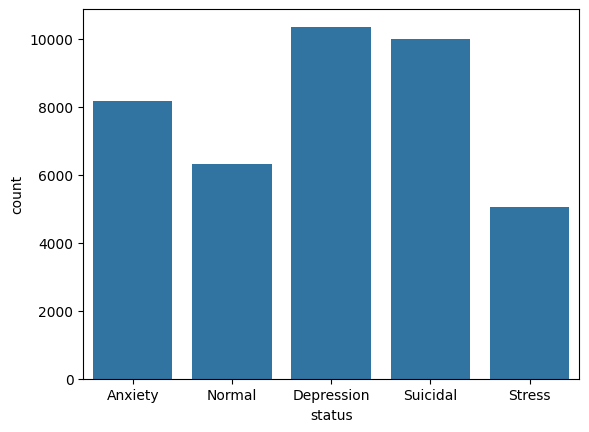

In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='status',data=augmented_df)
plt.show()

##text preprocessing

In [148]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [149]:
def clean_text(text):
  text=re.sub('[^a-zA-Z]',' ',text)
  text=text.lower()
  text=word_tokenize(text)
  text=[lemmatizer.lemmatize(word) for word in text if not word in stop_words]
  text=' '.join(text)
  return text

In [150]:
augmented_df['statement']=augmented_df['statement'].apply(clean_text)

In [151]:
augmented_df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress'],
      dtype=object)

In [152]:
cleen_data = augmented_df.copy()

In [153]:
cleen_data['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress'],
      dtype=object)

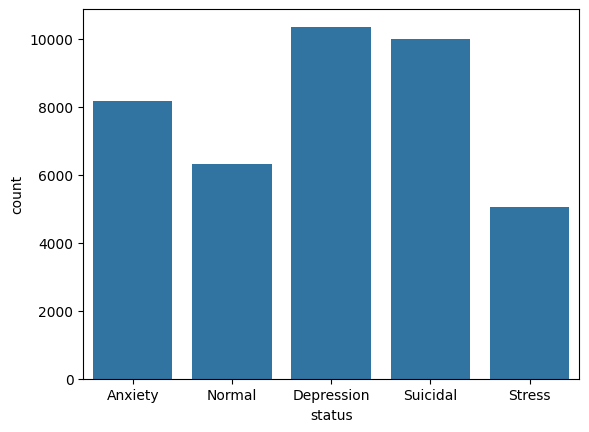

In [154]:
sns.countplot(x='status',data=cleen_data)
plt.show()

##spliting data

In [ ]:
from sklearn.model_selection import train_test_split ,StratifiedKFold,RandomizedSearchCV
x_train,x_test,y_train,y_test=train_test_split(
    cleen_data['statement'],
    cleen_data['status'],
    test_size=0.2,
    random_state=42,
    stratify=cleen_data['status'],
    shuffle=True
    )

In [156]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()


In [157]:
y_train=le.fit_transform(y_train)
y_test=le.transform(y_test)

In [158]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [159]:
%uv pip install xgboost

Using Python 3.12.6 environment at: /usr/local
Audited 1 package in 24ms
Note: you may need to restart the kernel to use updated packages.


In [160]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight


In [161]:

# --- Logistic Regression ---
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])
lr_params = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'saga'],
}

# --- Linear SVC ---
svc_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LinearSVC(class_weight='balanced', max_iter=2000))
])
svc_params = {
    'tfidf__max_features': [3000, 5000, 10000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__C': [0.01, 0.1, 1, 10, 100],
}

# --- Random Forest ---
rf_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])
rf_params = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 20, 40],
    'model__min_samples_split': [2, 5],
}

# --- XGBoost ---
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', XGBClassifier(
        objective='multi:softmax',
        num_class=5,
        eval_metric='mlogloss',
        random_state=42,
        tree_method='hist',
        device='cuda'
    ))
])
xgb_params = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__subsample': [0.7, 1.0],
}

In [162]:
configs = {
    'Logistic Regression': (lr_pipeline, lr_params, 10),
    'Linear SVC':          (svc_pipeline, svc_params, 8),
    'Random Forest':       (rf_pipeline, rf_params, 8),
    'XGBoost':             (xgb_pipeline, xgb_params, 8),
}

In [163]:
best_models = {}

for name, (pipeline, params, n_iter) in configs.items():
    print(f"\n{'='*50}")
    print(f"Tuning: {name}  (n_iter={n_iter})")
    print('='*50)

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=n_iter,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    search.fit(x_train, y_train)

    best_models[name] = search.best_estimator_
    print("="*40)
    print(f"\nBest CV Accuracy : {search.best_score_:.4f}")
    print(f"   Best Params      : {search.best_params_}")


Tuning: Logistic Regression  (n_iter=10)
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best CV Accuracy : 0.7604
   Best Params      : {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 5000, 'model__solver': 'saga', 'model__C': 1}

Tuning: Linear SVC  (n_iter=8)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best CV Accuracy : 0.7641
   Best Params      : {'tfidf__ngram_range': (1, 2), 'tfidf__max_features': 10000, 'model__C': 1}

Tuning: Random Forest  (n_iter=8)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best CV Accuracy : 0.7744
   Best Params      : {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 3000, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__max_depth': None}

Tuning: XGBoost  (n_iter=8)
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [05:18:37] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [05:18:38] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic


Best CV Accuracy : 0.2753
   Best Params      : {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 5000, 'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 7, 'model__learning_rate': 0.1}


In [165]:
print("\n" + "="*60)
print("FINAL TEST SET RESULTS \n \n")

results = {}
for name, model in best_models.items():
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{'='*50}")
    print(f"{name} — Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, zero_division=0))


FINAL TEST SET RESULTS 
 


Logistic Regression — Test Accuracy: 0.7618
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      1634
           1       0.70      0.63      0.66      2072
           2       0.83      0.94      0.88      1263
           3       0.71      0.79      0.75      1009
           4       0.70      0.69      0.70      1998

    accuracy                           0.76      7976
   macro avg       0.77      0.78      0.77      7976
weighted avg       0.76      0.76      0.76      7976


Linear SVC — Test Accuracy: 0.7713
              precision    recall  f1-score   support

           0       0.90      0.91      0.91      1634
           1       0.68      0.63      0.65      2072
           2       0.86      0.93      0.89      1263
           3       0.79      0.83      0.81      1009
           4       0.68      0.67      0.68      1998

    accuracy                           0.77      7976
   macro avg       0.7

/usr/local/lib/python3.12/site-packages/xgboost/core.py:751: UserWarning: [05:19:00] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


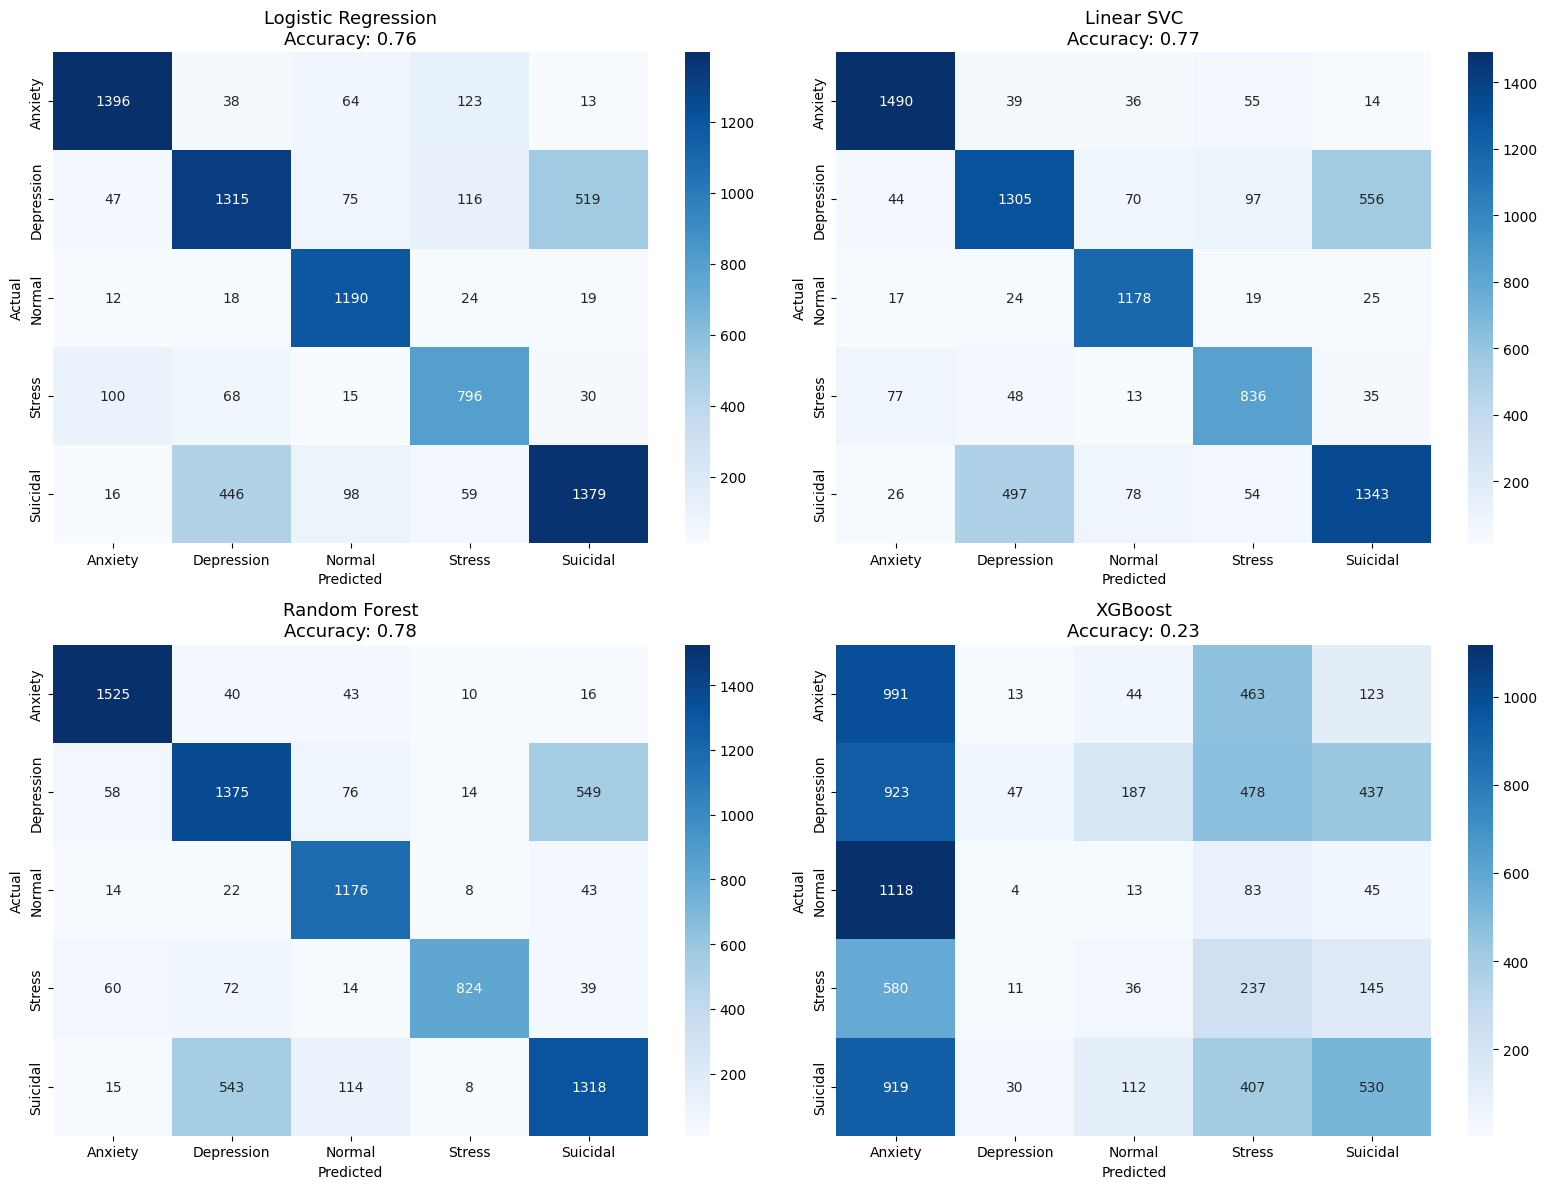

In [169]:
class_names = le.classes_

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(best_models.items()):
    y_pred = model.predict(x_test)
    
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[idx]
    )
    
    acc = accuracy_score(y_test, y_pred)
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.2f}', fontsize=13)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [164]:
for name in best_models:
    joblib.dump(best_models[name], f'best_{name.replace(" ", "_")}.pkl')


✅ Saved: Logistic Regression
✅ Saved: Linear SVC
✅ Saved: Random Forest
✅ Saved: XGBoost


In [166]:
import joblib
joblib.dump(le,'label_encoder.pkl')
print(le.classes_)

['Anxiety' 'Depression' 'Normal' 'Stress' 'Suicidal']


In [167]:
import numpy, sklearn, xgboost, joblib
print("numpy:", numpy.__version__)
print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("joblib:", joblib.__version__)

numpy: 2.1.2
sklearn: 1.7.1
xgboost: 3.2.0
joblib: 1.5.2


In [168]:
for label in new_df['status'].unique():
    sample = new_df[new_df['status'] == label]['statement'].iloc[0]
    print(f"{label}: {sample}\n")

Anxiety: oh my gosh

Normal: Gr gr dreaming of ex crush to be my game, God

Depression: I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?

Suicidal: I am so exhausted of this. Just when I think I can finally rest, just when I think maybe things are starting to settle, another hurdle comes flying at me. This month alone we found out my mum could be dying, my girlfriend left me, my parents revealed that they wanted a divorce, my grandad was hospitalised again and just now my little sister's been rushed 